# Convolutional Neural Network (CNN) on CIFAR - 10 using PyTorch


This project implements a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset.

### This Notebook: 
Dataset: CIFAR-10 (32x32 RGB images)

Model: CNN with convolutional + fully connected layers

Evaluation: Training vs Test Accuracy & Loss

Visualization: Loss and Accuracy plots over epochs


### I am using CIFAR- 10 as my dataset because:
- It’s more realistic than MNIST (real-world objects - cars, animals, planes)
- It tests CNN properly (CNNs are designed for: patterns, textures, colors & CIFAR-10 has: RGB images (3 channels), complex backgrounds)
- It is more challenging and creates more interesting results


In [9]:
# Import libraries
import torch
import torch.nn as nn 
import torch.optim as optim  #training model
import torchvision #gives datasets like CIFAR-10
import torchvision.transforms as transforms #preprocessing images
import matplotlib.pyplot as plt

In [11]:
# Transformations for CIFAR-10 (3 channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Loads dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

len(train_dataset), len(test_dataset)

(50000, 10000)

In [13]:
# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Convolution layers (extract features from images)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # takes RGB image → 16 feature maps
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # 16 → 32 feature maps
        
        self.relu = nn.ReLU()        # activation function
        self.pool = nn.MaxPool2d(2, 2)  # reduces image size
        
        # Fully connected layers (used for final classification)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)  # flatten → 128 neurons
        self.fc2 = nn.Linear(128, 10)          # 10 output classes
    
    def forward(self, x):
        # Apply convolution → activation → pooling
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten the data for fully connected layers
        x = x.view(-1, 32 * 8 * 8)
        
        # Final classification layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
         
        # Return final output
        return x

# Create the model
model = CNN()

In [15]:
# Loss function (measures how wrong the model’s predictions are)
criterion = nn.CrossEntropyLoss()

# Optimizer (updates the model to improve performance)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # learning rate controls how fast the model learns

In [17]:
# Lists to store results for plotting later
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

epochs = 10  # number of times the model sees the full dataset

for epoch in range(epochs):
    
    model.train()  # set model to training mode
    running_loss = 0
    correct = 0
    total = 0
    
 # TRAINING 
    for images, labels in train_loader:
        
        optimizer.zero_grad()  # clear previous gradients
        
        outputs = model(images)  # forward pass (make predictions)
        loss = criterion(outputs, labels)  # calculate loss
        
        loss.backward()  # backpropagation (compute gradients)
        optimizer.step()  # update model weights
        
        running_loss += loss.item()  # store loss
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Average training results
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
# TESTING 
    model.eval()  # set model to evaluation mode
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():  # no gradient calculation (faster)
        for images, labels in test_loader:
            
            outputs = model(images)  # predictions
            loss = criterion(outputs, labels)  # loss
            
            test_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Average test results
    test_loss /= len(test_loader)
    test_acc = correct / total
    
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # Print results for each epoch
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/10 | Train Loss: 1.4250 | Train Acc: 0.4887 | Test Loss: 1.2315 | Test Acc: 0.5615
Epoch 2/10 | Train Loss: 1.0769 | Train Acc: 0.6205 | Test Loss: 1.0320 | Test Acc: 0.6331
Epoch 3/10 | Train Loss: 0.9290 | Train Acc: 0.6736 | Test Loss: 0.9568 | Test Acc: 0.6599
Epoch 4/10 | Train Loss: 0.8325 | Train Acc: 0.7073 | Test Loss: 0.9336 | Test Acc: 0.6761
Epoch 5/10 | Train Loss: 0.7562 | Train Acc: 0.7361 | Test Loss: 0.9069 | Test Acc: 0.6862
Epoch 6/10 | Train Loss: 0.6846 | Train Acc: 0.7590 | Test Loss: 0.9173 | Test Acc: 0.6869
Epoch 7/10 | Train Loss: 0.6173 | Train Acc: 0.7838 | Test Loss: 0.9107 | Test Acc: 0.6984
Epoch 8/10 | Train Loss: 0.5522 | Train Acc: 0.8064 | Test Loss: 0.9262 | Test Acc: 0.6981
Epoch 9/10 | Train Loss: 0.4958 | Train Acc: 0.8271 | Test Loss: 0.9427 | Test Acc: 0.6966
Epoch 10/10 | Train Loss: 0.4435 | Train Acc: 0.8442 | Test Loss: 0.9912 | Test Acc: 0.7051


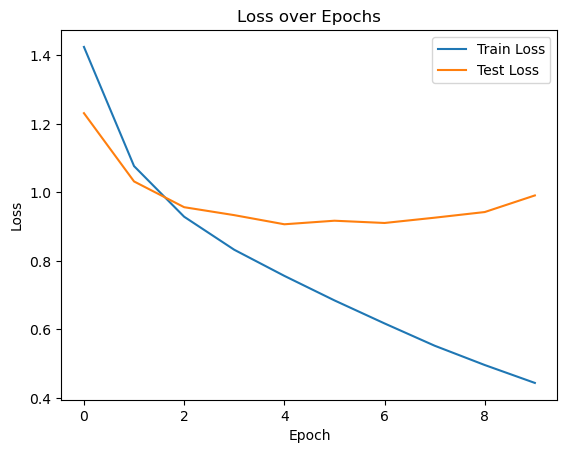

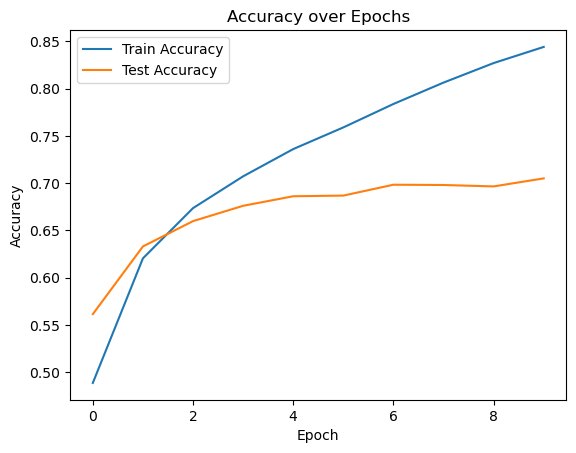

In [19]:
# Loss plot
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy plot
plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# Conclusion: 
